# Блок 2 — Разведочный анализ (EDA)

**Задача проекта.** Предсказать, оставит ли клиент негативный отзыв (1–2 звезды)
по данным, известным в момент вручения заказа. Цель EDA — понять, какие факторы
вообще связаны с негативом и на что опираться при отборе признаков.

**Откуда данные.** Все разрезы считаются SQL-запросами из `sql/04_analytics.sql`
по витрине `order_features` (`sql/03_features.sql`): 95 824 доставленных заказа
с отзывом, доля целевого класса 12,8 %. Ноутбук ничего не агрегирует сам —
он выполняет именованный запрос и рисует его результат. То же самое можно
получить без ноутбука: `python src/build_features.py --analytics`.

**Как воспроизвести:**

```
pip install -r requirements.txt
python src/build_db.py          # CSV -> db/olist.db
python src/build_features.py    # витрина order_features + проверки
```

затем выполнить этот ноутбук целиком (`Run All`). Графики сохраняются
в `reports/figures/` — оттуда они идут в презентацию.

In [1]:
import sqlite3
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from matplotlib.patches import Patch

# Ноутбук запускается из notebooks/, скрипты и база — от корня проекта
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / "src"))

# Тот же разборщик файла запросов, что и у раннера: один источник правды
from build_features import split_named_queries  # noqa: E402

DB_PATH = PROJECT_ROOT / "db" / "olist.db"
ANALYTICS_SQL = PROJECT_ROOT / "sql" / "04_analytics.sql"
FIG_DIR = PROJECT_ROOT / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

conn = sqlite3.connect(DB_PATH)
QUERIES = {
    code: (title, body)
    for code, title, body in split_named_queries(ANALYTICS_SQL.read_text(encoding="utf-8"))
}


def q(code: str) -> pd.DataFrame:
    """Выполняет запрос [code] из sql/04_analytics.sql."""
    title, body = QUERIES[code]
    print(f"[{code}] {title}")
    return pd.read_sql_query(body, conn)


def pc(value: float, digits: int = 1) -> str:
    """Процент с запятой — как принято в русском тексте."""
    return f"{value:.{digits}f} %".replace(".", ",")


def save(fig, name: str) -> None:
    fig.savefig(FIG_DIR / name)
    print(f"сохранено: reports/figures/{name}")


sns.set_theme(style="whitegrid")
plt.rcParams.update(
    {
        "figure.dpi": 110,
        "savefig.dpi": 150,
        "savefig.bbox": "tight",
        "axes.titlesize": 13,
        "axes.titleweight": "bold",
        "font.size": 10,
    }
)

BAD, OK, GREY = "#c0392b", "#2e86c1", "#95a5a6"

print(f"запросов в {ANALYTICS_SQL.name}: {len(QUERIES)} -> {', '.join(QUERIES)}")

запросов в 04_analytics.sql: 10 -> A1, A2, A3, A4, A5, A6, A7, A8, A9, A10


In [2]:
# Базовые цифры выборки — к ним дальше сравниваются все разрезы
overview = pd.read_sql_query(
    """
    SELECT COUNT(*)                                  AS orders,
           SUM(target)                               AS negative,
           ROUND(100.0 * AVG(target), 2)             AS target_pct,
           SUM(is_late)                              AS late_orders,
           ROUND(100.0 * AVG(is_late), 2)            AS late_pct,
           ROUND(AVG(delivery_days), 1)              AS avg_delivery_days,
           MIN(DATE(order_purchase_timestamp))       AS first_purchase,
           MAX(DATE(order_purchase_timestamp))       AS last_purchase
    FROM order_features
    """,
    conn,
)
BASE_RATE = float(overview.target_pct[0])
overview.T.rename(columns={0: "значение"})

,значение
orders,95824
negative,12262
target_pct,12.8
late_orders,6381
late_pct,6.66
avg_delivery_days,12.5
first_purchase,2016-09-15
last_purchase,2018-08-29


---
## 1. Целевая переменная: распределение оценок

[A1] Распределение оценок и вклад каждой в целевой класс


сохранено: reports/figures/01_review_score_distribution.png


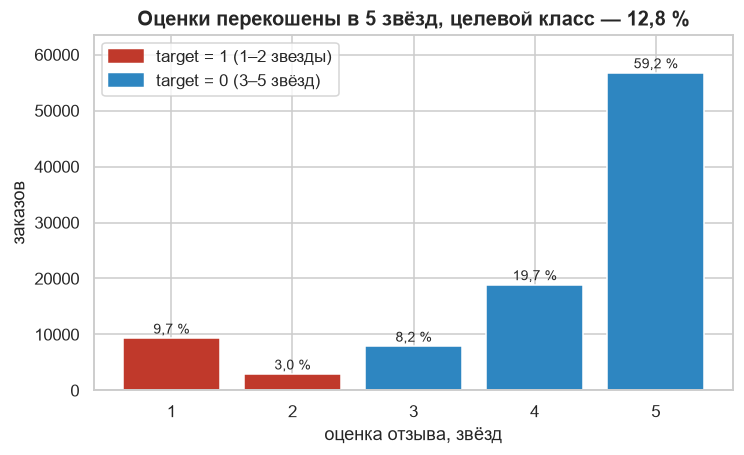

,review_score,orders,pct,is_target
0,1,9340,9.7,1
1,2,2922,3.0,1
2,3,7902,8.2,0
3,4,18893,19.7,0
4,5,56767,59.2,0


In [3]:
a1 = q("A1")

fig, ax = plt.subplots(figsize=(7.5, 4.2))
bars = ax.bar(
    a1.review_score.astype(str),
    a1.orders,
    color=[BAD if t else OK for t in a1.is_target],
)
for bar, pct in zip(bars, a1.pct):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 800,
        pc(pct),
        ha="center",
        fontsize=9,
    )
ax.set_title(f"Оценки перекошены в 5 звёзд, целевой класс — {pc(BASE_RATE)}")
ax.set_xlabel("оценка отзыва, звёзд")
ax.set_ylabel("заказов")
ax.set_ylim(0, a1.orders.max() * 1.12)
ax.legend(
    handles=[
        Patch(color=BAD, label="target = 1 (1–2 звезды)"),
        Patch(color=OK, label="target = 0 (3–5 звёзд)"),
    ],
    loc="upper left",
)
save(fig, "01_review_score_distribution.png")
plt.show()

a1

**Вывод.** Оценки распределены очень неравномерно: 59,2 % заказов получают
5 звёзд, а на целевой класс приходится всего 12,8 % выборки. Внутри негатива
перекос ещё сильнее: 9 340 отзывов из 12 262 — это одна звезда. Недовольный
клиент почти не ставит две звезды, он сразу ставит одну.

Из этого следуют два решения для блока ML.

**Метрика.** Классы соотносятся как 1 : 7, поэтому accuracy здесь ничего
не измеряет: модель, которая всегда отвечает «отзыв будет хороший», получит
87 % точности и нулевую пользу. Основная метрика — PR-AUC.

**Порог.** Граница `score <= 2` не режет однородную массу пополам, а отделяет
явный провал от всего остального. Это понятное бизнес-событие, а не
произвольно выбранное число.

---
## 2. Главный график: опоздание относительно обещанной даты

[A2] ГЛАВНЫЙ РАЗРЕЗ: опоздание против обещанной даты -> доля негатива


сохранено: reports/figures/02_delay_vs_negative.png


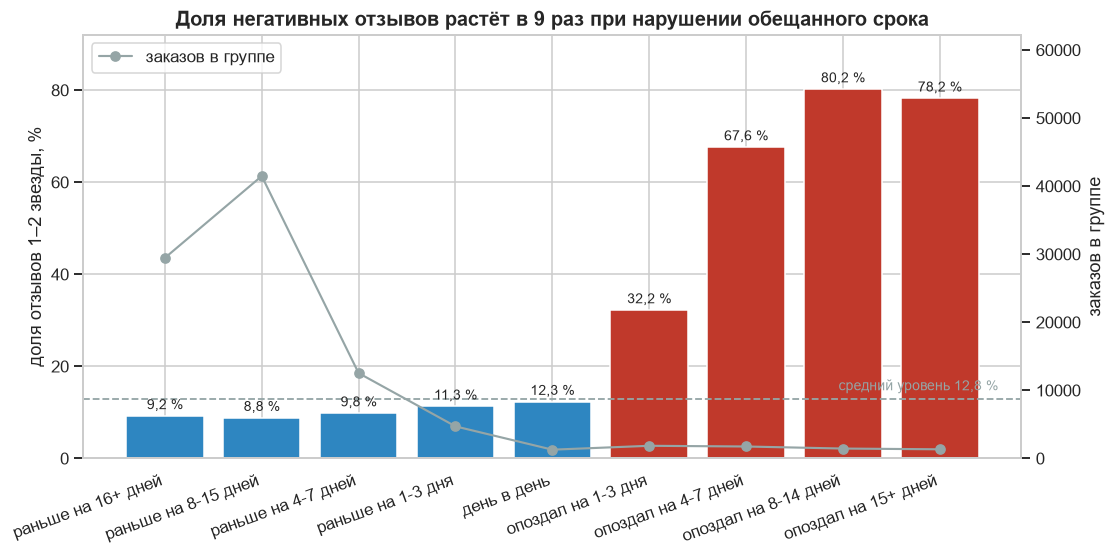

,delay_bucket,orders,share_pct,bad_review_pct
0,a) раньше на 16+ дней,29453,30.7,9.2
1,b) раньше на 8-15 дней,41476,43.3,8.8
2,c) раньше на 4-7 дней,12529,13.1,9.8
3,d) раньше на 1-3 дня,4705,4.9,11.3
4,e) день в день,1280,1.3,12.3
5,f) опоздал на 1-3 дня,1852,1.9,32.2
6,g) опоздал на 4-7 дней,1748,1.8,67.6
7,h) опоздал на 8-14 дней,1446,1.5,80.2
8,i) опоздал на 15+ дней,1335,1.4,78.2


In [4]:
a2 = q("A2")
labels = a2.delay_bucket.str[3:]

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(
    labels,
    a2.bad_review_pct,
    color=["#c0392b" if "опозд" in b else OK for b in labels],
)
for bar, value in zip(bars, a2.bad_review_pct):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1.5,
        pc(value),
        ha="center",
        fontsize=9,
    )
ax.axhline(BASE_RATE, color=GREY, ls="--", lw=1.2)
ax.text(
    len(labels) - 0.4,
    BASE_RATE + 2,
    f"средний уровень {pc(BASE_RATE)}",
    ha="right",
    color=GREY,
    fontsize=9,
)
ax.set_title("Доля негативных отзывов растёт в 9 раз при нарушении обещанного срока")
ax.set_ylabel("доля отзывов 1–2 звезды, %")
ax.set_ylim(0, 92)
ax.tick_params(axis="x", labelrotation=20)
for tick in ax.get_xticklabels():
    tick.set_ha("right")

volume = ax.twinx()
volume.plot(labels, a2.orders, color=GREY, marker="o", lw=1.4, label="заказов в группе")
volume.set_ylabel("заказов в группе")
volume.set_ylim(0, a2.orders.max() * 1.5)   # чтобы пик линии не упирался в рамку
volume.grid(False)
volume.legend(loc="upper left")

save(fig, "02_delay_vs_negative.png")
plt.show()

a2

In [5]:
# Сколько негатива даёт небольшая группа опоздавших
late_share = pd.read_sql_query(
    """
    SELECT SUM(is_late)                                              AS late_orders,
           ROUND(100.0 * AVG(is_late), 1)                            AS late_share_pct,
           SUM(CASE WHEN is_late = 1 THEN target END)                AS negative_from_late,
           ROUND(100.0 * SUM(CASE WHEN is_late = 1 THEN target END)
                 / SUM(target), 1)                                   AS share_of_all_negative_pct
    FROM order_features
    """,
    conn,
)
late_share

,late_orders,late_share_pct,negative_from_late,share_of_all_negative_pct
0,6381,6.7,3980,32.5


**Вывод.** Это самая сильная зависимость в данных, и она нелинейная.

Пока заказ приходит в срок или раньше, доля негатива держится около 9 %
и почти не зависит от того, насколько раньше он пришёл. Доставка за две недели
до обещанной даты выигрыша не даёт: 9,2 % негатива против 8,8 % у тех, кто
приехал на 8–15 дней раньше. Досрочную доставку клиент просто не замечает.

Перелом происходит ровно на нуле. День в день — 12,3 % негатива, опоздание
на 1–3 дня — уже 32,2 %, на 4–7 дней — 67,6 %, на 8–14 дней — 80,2 %. Дальше
кривая выходит на плато: опоздать на две недели или на два месяца для клиента
одинаково плохо.

Теперь масштаб. Опоздавших заказов всего 6 381, это 6,7 % выборки, но они дают
3 980 негативных отзывов, **треть всего негатива (32,5 %)**. Поэтому
`delay_vs_estimate_days` и `is_late` идут в модель первыми, а рекомендация
для бизнеса будет строиться вокруг срока: дешевле не обещать короткую доставку,
чем потом отрабатывать испорченный отзыв.

---
## 3. Абсолютный срок доставки

[A3] Срок доставки в днях -> доля негатива


сохранено: reports/figures/03_delivery_days_vs_negative.png


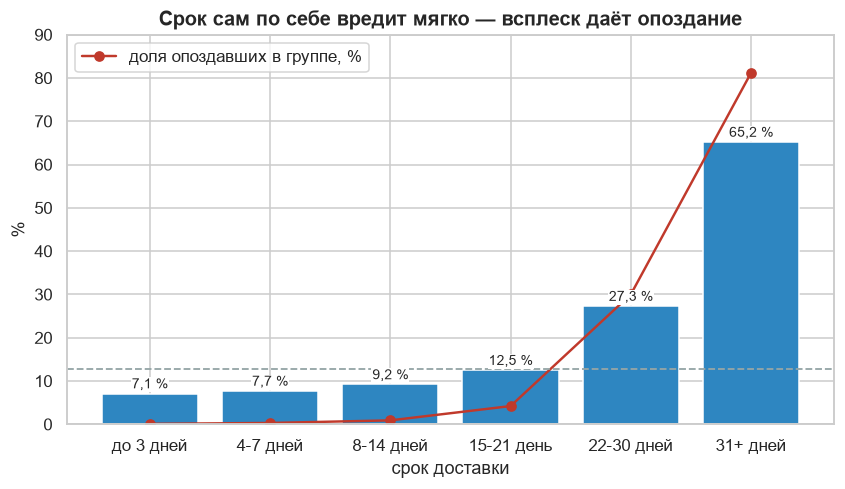

,delivery_bucket,orders,bad_review_pct,late_pct
0,a) до 3 дней,8563,7.1,0.1
1,b) 4-7 дней,24975,7.7,0.3
2,c) 8-14 дней,36190,9.2,0.9
3,d) 15-21 день,15262,12.5,4.2
4,e) 22-30 дней,6826,27.3,30.0
5,f) 31+ дней,4008,65.2,81.2


In [6]:
a3 = q("A3")
labels3 = a3.delivery_bucket.str[3:]

fig, ax = plt.subplots(figsize=(9, 4.6))
bars = ax.bar(labels3, a3.bad_review_pct, color=OK)
for bar, value, late in zip(bars, a3.bad_review_pct, a3.late_pct):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1.2,
        pc(value),
        ha="center",
        fontsize=9,
        bbox=dict(facecolor="white", edgecolor="none", pad=0.6),
    )
ax.plot(labels3, a3.late_pct, color=BAD, marker="o", lw=1.6, label="доля опоздавших в группе, %")
ax.axhline(BASE_RATE, color=GREY, ls="--", lw=1.2)
ax.set_title("Срок сам по себе вредит мягко — всплеск даёт опоздание")
ax.set_xlabel("срок доставки")
ax.set_ylabel("%")
ax.set_ylim(0, 90)
ax.legend(loc="upper left")
save(fig, "03_delivery_days_vs_negative.png")
plt.show()

a3

**Вывод.** Абсолютный срок доставки тоже влияет, но гораздо слабее.
На интервале, который покрывает 89 % заказов, доля негатива растёт всего
с 7,1 % (доставка за три дня) до 12,5 % (15–21 день), то есть меньше чем вдвое.
Резкий взлёт начинается там, где ожидание перестаёт укладываться в обещание:
в группе «31+ дней» негатива уже 65,2 %, и одновременно 81,2 % таких заказов
опоздали. Красная линия на графике показывает, что два последних столбца — это
по сути те же опоздавшие заказы из раздела 2.

Значит, `delivery_days` и `delay_vs_estimate_days` несут разную информацию
и нужны оба: первый измеряет терпение клиента, второй — нарушенное обещание.
Для бизнеса вывод ещё практичнее: ускорять доставку с 10 дней до 7 почти
не окупается, а держать обещанный срок окупается сразу.

---
## 4. Категории товара (топ-15 по объёму)

[A4] Категории товара: топ-15 по объёму заказов


сохранено: reports/figures/04_category_vs_negative.png


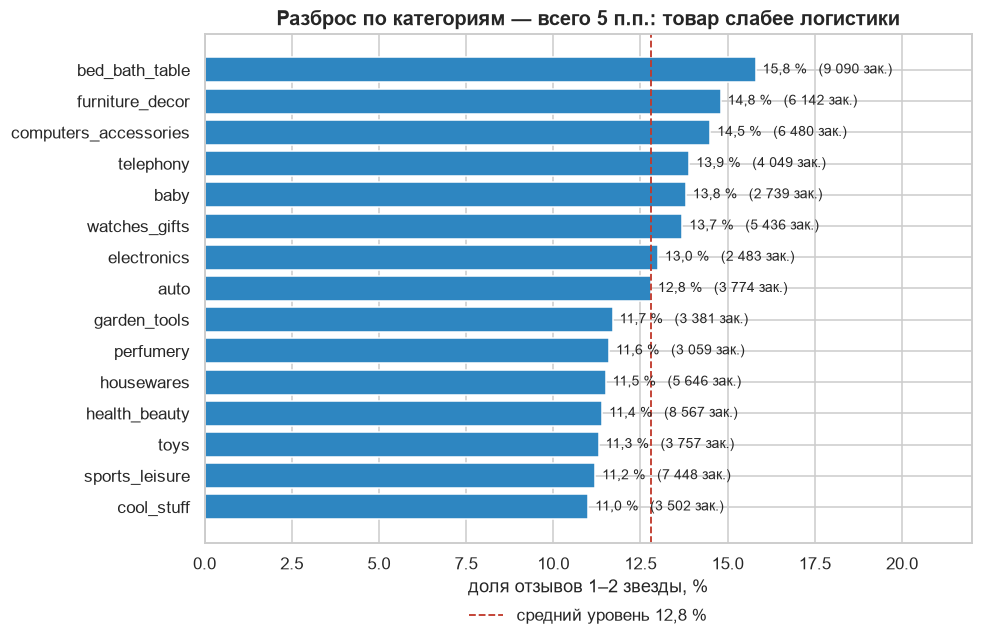

,main_category,orders,bad_review_pct,avg_delivery_days,late_pct,avg_item_price
0,bed_bath_table,9090,15.8,13.0,7.3,97.0
1,health_beauty,8567,11.4,12.1,7.4,136.0
2,sports_leisure,7448,11.2,12.2,6.5,118.0
3,computers_accessories,6480,14.5,13.1,6.3,117.0
4,furniture_decor,6142,14.8,13.1,7.1,96.0
5,housewares,5646,11.5,11.1,5.3,96.0
6,watches_gifts,5436,13.7,12.8,7.3,207.0
7,telephony,4049,13.9,13.0,7.1,71.0
8,auto,3774,12.8,12.3,7.2,142.0
9,toys,3757,11.3,11.7,6.2,120.0


In [7]:
a4 = q("A4").sort_values("bad_review_pct")

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(a4.main_category, a4.bad_review_pct, color=OK)
for bar, value, orders in zip(bars, a4.bad_review_pct, a4.orders):
    ax.text(value + 0.2, bar.get_y() + bar.get_height() / 2,
            f"{pc(value)}   (" + f"{orders:,}".replace(",", " ") + " зак.)",
            va="center", fontsize=9)
ax.axvline(BASE_RATE, color=BAD, ls="--", lw=1.2, label=f"средний уровень {pc(BASE_RATE)}")
ax.set_title("Разброс по категориям — всего 5 п.п.: товар слабее логистики")
ax.set_xlabel("доля отзывов 1–2 звезды, %")
ax.set_xlim(0, 22)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.1), frameon=False)
save(fig, "04_category_vs_negative.png")
plt.show()

a4.sort_values("orders", ascending=False)

**Вывод.** Категория товара сама по себе слабый предиктор. Между лучшей
и худшей крупной категорией всего 4,8 п. п. разницы (`cool_stuff` — 11,0 %,
`bed_bath_table` — 15,8 %), тогда как опоздание меняет долю негатива
в девять раз.

Часть этой разницы к тому же объясняется не товаром, а логистикой.
У `bed_bath_table` и `furniture_decor` (крупногабаритное и хрупкое) доля
опозданий 7,3 % и 7,1 % при среднем 6,7 %, а срок доставки 13 дней против
11,1 у `housewares`. Цена с негативом почти не связана: `watches_gifts`
со средним чеком 207 R$ даёт 13,7 %, а `electronics` с чеком 56 R$ — 13,0 %.

Что делаем с признаком: берём топ-N категорий плюс `other`. Раскладывать
74 категории в one-hot ради 5 п. п. сигнала не стоит, получится разреженная
матрица без отдачи. Заказы без категории (1 349 штук) оставляем отдельным
значением `unknown`, подробнее в разделе 6.

---
## 5. География: штат покупателя

[A5] Штаты покупателя: объём, негатив, логистика


сохранено: reports/figures/05_state_vs_negative.png


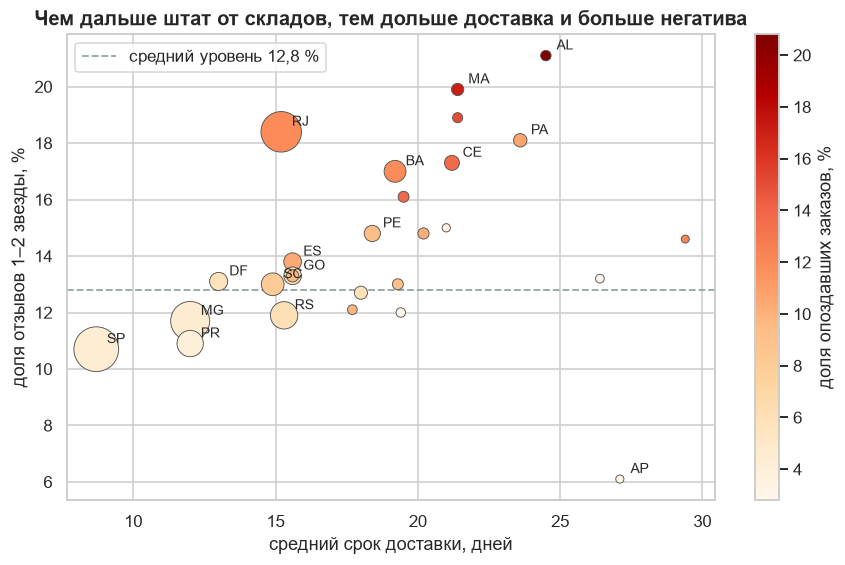

,customer_state,orders,bad_review_pct,avg_delivery_days,late_pct,avg_freight
0,SP,40266,10.7,8.7,4.4,17.33
1,RJ,12211,18.4,15.2,11.9,23.92
2,MG,11285,11.7,12.0,4.5,23.43
3,RS,5326,11.9,15.3,6.0,24.81
4,PR,4900,10.9,12.0,4.0,23.52
5,SC,3519,13.0,14.9,8.1,24.81
6,BA,3229,17.0,19.2,11.9,29.97
7,DF,2070,13.1,13.0,5.7,23.83
8,ES,1969,13.8,15.6,10.4,24.46
9,GO,1946,13.3,15.6,6.4,26.09


In [8]:
a5 = q("A5")

fig, ax = plt.subplots(figsize=(9.5, 5.5))
ax.scatter(
    a5.avg_delivery_days,
    a5.bad_review_pct,
    s=a5.orders.clip(upper=15000) / 18 + 25,
    c=a5.late_pct,
    cmap="OrRd",
    edgecolor="#555555",
    linewidth=0.6,
    zorder=3,
)
for _, row in a5.iterrows():
    if row.orders >= 900 or row.bad_review_pct > 19 or row.bad_review_pct < 9:
        ax.annotate(
            row.customer_state,
            (row.avg_delivery_days, row.bad_review_pct),
            textcoords="offset points",
            xytext=(7, 4),
            fontsize=9,
        )
ax.axhline(BASE_RATE, color=GREY, ls="--", lw=1.2,
           label=f"средний уровень {pc(BASE_RATE)}")
ax.legend(loc="upper left")
ax.set_title("Чем дальше штат от складов, тем дольше доставка и больше негатива")
ax.set_xlabel("средний срок доставки, дней")
ax.set_ylabel("доля отзывов 1–2 звезды, %")
bar = fig.colorbar(ax.collections[0], ax=ax)
bar.set_label("доля опоздавших заказов, %")
save(fig, "05_state_vs_negative.png")
plt.show()

a5.head(12)

**Вывод.** Региональный разброс заметен. Сан-Паулу (SP): 40 266 заказов,
средний срок 8,7 дня, 10,7 % негатива. Рио-де-Жанейро (RJ): 15,2 дня
и 18,4 %. Северо-восточные штаты вроде AL и MA ждут заказ 24,5 и 21,4 дня
и дают 21,1 % и 19,9 % негатива.

Точки на графике выстраиваются вдоль линии «дольше везём — хуже оценка»,
а цвет показывает, что дело не в самом расстоянии, а в срывах срока:
в AL опаздывает каждый пятый заказ (20,8 %), в SP — каждый двадцать второй
(4,4 %).

Мелкие штаты по отдельности читать нельзя: за 6,1 % негатива в AP стоят
66 заказов, доверительный интервал там шире самого эффекта. Штат берём
в модель как категориальный признак, но оценивать его вклад нужно вместе
с логистическими. Это разделение сделано в разделе 9.

---
## 6. Карта пропусков и стратегия их обработки

[A6] Карта пропусков по витрине


сохранено: reports/figures/06_missing_map.png


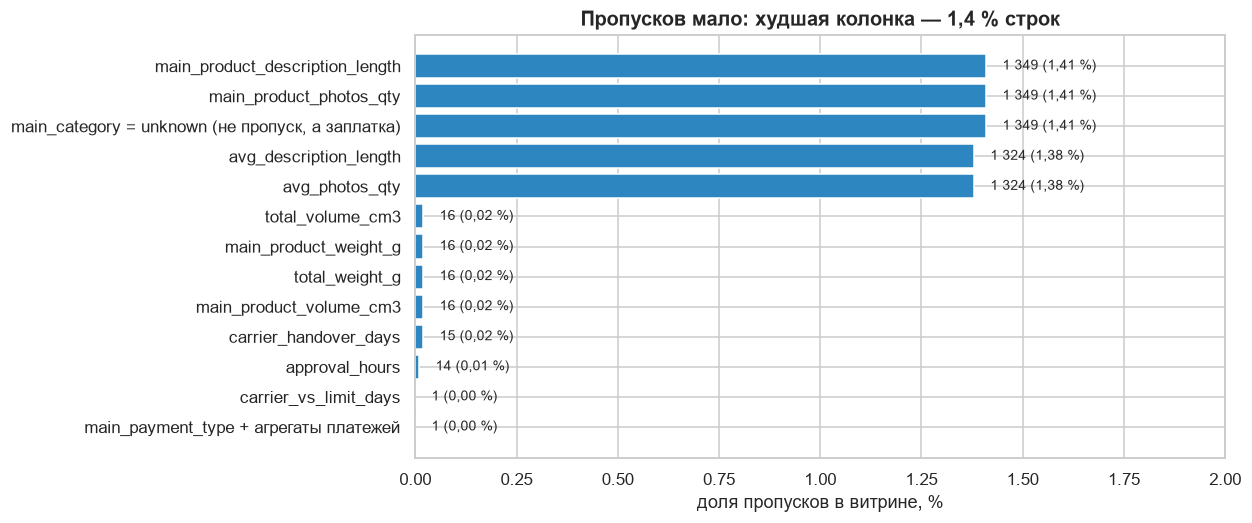

,column_name,nulls,null_pct
0,main_product_photos_qty,1349,1.41
1,main_product_description_length,1349,1.41
2,"main_category = unknown (не пропуск, а заплатка)",1349,1.41
3,avg_photos_qty,1324,1.38
4,avg_description_length,1324,1.38
6,main_product_volume_cm3,16,0.02
8,total_volume_cm3,16,0.02
7,total_weight_g,16,0.02
5,main_product_weight_g,16,0.02
9,carrier_handover_days,15,0.02


In [9]:
a6 = q("A6").sort_values("nulls")

fig, ax = plt.subplots(figsize=(9.5, 5))
bars = ax.barh(a6.column_name, a6.null_pct, color=OK)
for bar, nulls, pct in zip(bars, a6.nulls, a6.null_pct):
    ax.text(pct + 0.04, bar.get_y() + bar.get_height() / 2,
            f"{nulls:,}".replace(",", " ") + f" ({pc(pct, 2)})", va="center", fontsize=9)
ax.set_title("Пропусков мало: худшая колонка — 1,4 % строк")
ax.set_xlabel("доля пропусков в витрине, %")
ax.set_xlim(0, 2.0)
save(fig, "06_missing_map.png")
plt.show()

a6.sort_values("nulls", ascending=False)

**Вывод.** Данные оказались на удивление полными: 30 колонок витрины из 43
заполнены целиком (проверяется в `build_features.py`). Худший случай —
1 349 заказов (1,41 %), у которых не заполнена карточка главного товара.
Причём это один и тот же набор строк: если нет категории, то нет ни числа
фотографий, ни описания.

Принятая стратегия:

| Что | Сколько | Решение |
|---|---|---|
| нет категории товара | 1 349 (1,41 %) | отдельное значение `unknown` — сам пропуск уже сигнал: такие карточки заводили небрежно |
| нет фото и описания | 1 349 / 1 324 | медиана по категории плюс бинарный флаг «карточка не заполнена» |
| нет веса и габаритов | 16 (0,02 %) | медиана по категории |
| нет `order_approved_at` или даты передачи курьеру | 14–15 | медиана; флаг не нужен, объём ничтожен |
| нет данных об оплате | 1 заказ | оставляем пропуск, дерево справится; для линейной модели медиана |
| заказ не доставлен или нет даты вручения | 3 617 заказов вне витрины | исключены на уровне SQL: цель считается только для дошедших заказов |

Медиану для дозаполнения считаем **только по обучающей выборке** и переносим
на тест. Иначе в модель попадёт статистика всего датасета, а это утечка.

---
## 7. Состав заказа: позиции и продавцы

[A7] Состав заказа: число позиций и число продавцов


сохранено: reports/figures/07_order_composition.png


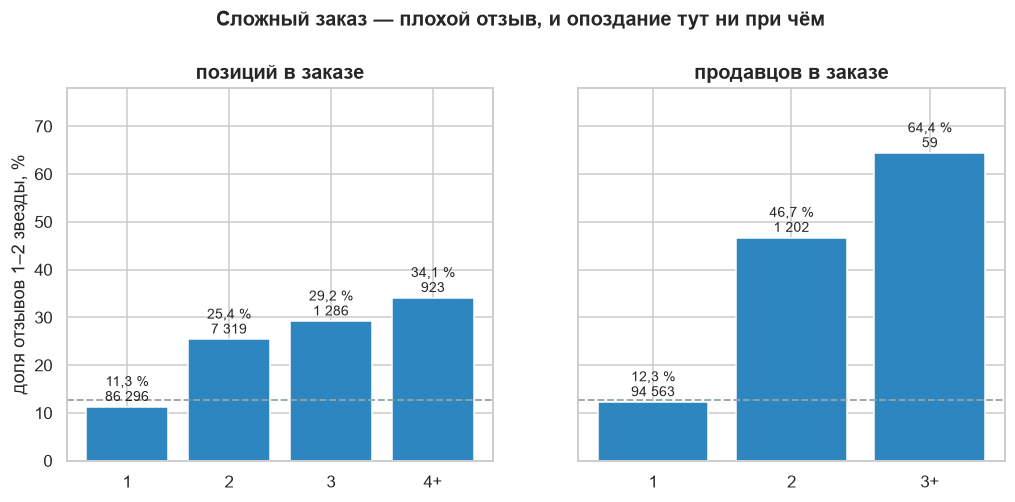

,dim,bucket,orders,bad_review_pct,late_pct
0,позиций в заказе,1,86296,11.3,6.8
1,позиций в заказе,2,7319,25.4,5.2
2,позиций в заказе,3,1286,29.2,4.8
3,позиций в заказе,4+,923,34.1,5.0
4,продавцов в заказе,1,94563,12.3,6.7
5,продавцов в заказе,2,1202,46.7,1.0
6,продавцов в заказе,3+,59,64.4,0.0


In [10]:
a7 = q("A7")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.4), sharey=True)
for ax, (dim, part) in zip(axes, a7.groupby("dim", sort=False)):
    bars = ax.bar(part.bucket, part.bad_review_pct, color=OK)
    for bar, value, orders in zip(bars, part.bad_review_pct, part.orders):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1.2,
                f"{pc(value)}\n" + f"{orders:,}".replace(",", " "),
                ha="center", fontsize=9)
    ax.axhline(BASE_RATE, color=GREY, ls="--", lw=1.2)
    ax.set_title(dim)
    ax.set_ylim(0, 78)
axes[0].set_ylabel("доля отзывов 1–2 звезды, %")
fig.suptitle("Сложный заказ — плохой отзыв, и опоздание тут ни при чём",
             fontsize=13, fontweight="bold", y=1.04)
save(fig, "07_order_composition.png")
plt.show()

a7

**Вывод.** Зависимость сильная и монотонная. Заказ из одной позиции даёт
11,3 % негатива, из двух — 25,4 %, из четырёх и больше — 34,1 %. По числу
продавцов ещё резче: один продавец — 12,3 %, два — 46,7 %, три и больше —
64,4 %.

Самое интересное в колонке `late_pct`. У заказов с двумя продавцами доля
опоздавших **ниже** средней: 1,0 % против 6,7 %. То есть срок здесь ни при чём,
негатив берётся откуда-то ещё. Рабочая гипотеза такая: в витрине
`order_delivered_customer_date` — одна дата на весь заказ, а посылки от разных
продавцов едут отдельно. Клиент ставит оценку, когда часть коробок ещё в пути.

Проверить гипотезу на этих данных нельзя, дат по отдельным позициям нет.
Признаки `items_count` и `distinct_sellers` в модель берём, но при
интерпретации помним: это скорее «сложность заказа», чем «вина склада».
Заказов с двумя и более продавцами всего 1 261 (1,3 %), на общую метрику они
влияют слабо, зато дают точную мишень для операционных улучшений.

---
## 8. Оплата: способ и рассрочка

[A8] Оплата: способ и рассрочка


сохранено: reports/figures/08_payment_vs_negative.png


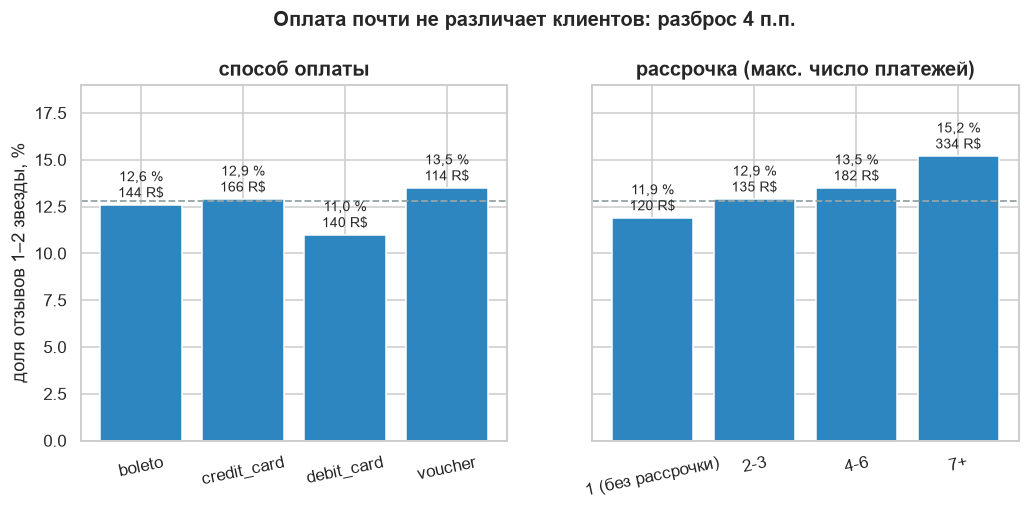

,dim,bucket,orders,bad_review_pct,avg_payment
0,рассрочка (макс. число платежей),1 (без рассрочки),46517,11.9,120.0
1,рассрочка (макс. число платежей),2-3,22013,12.9,135.0
2,рассрочка (макс. число платежей),4-6,15631,13.5,182.0
3,рассрочка (макс. число платежей),7+,11662,15.2,334.0
4,рассрочка (макс. число платежей),нет данных,1,100.0,NaN
5,способ оплаты,credit_card,72331,12.9,166.0
6,способ оплаты,boleto,19062,12.6,144.0
7,способ оплаты,voucher,2953,13.5,114.0
8,способ оплаты,debit_card,1477,11.0,140.0
9,способ оплаты,нет данных,1,100.0,NaN


In [11]:
a8 = q("A8")
a8_plot = a8[a8.bucket != "нет данных"]
DIM_ORDER = ["способ оплаты", "рассрочка (макс. число платежей)"]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), sharey=True)
for ax, dim in zip(axes, DIM_ORDER):
    part = a8_plot[a8_plot.dim == dim].sort_values("bucket")
    bars = ax.bar(part.bucket, part.bad_review_pct, color=OK)
    for bar, value, payment in zip(bars, part.bad_review_pct, part.avg_payment):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.4,
                f"{pc(value)}\n{payment:.0f} R$", ha="center", fontsize=9)
    ax.axhline(BASE_RATE, color=GREY, ls="--", lw=1.2)
    ax.set_title(dim)
    ax.set_ylim(0, 19)
    ax.tick_params(axis="x", labelrotation=12)
axes[0].set_ylabel("доля отзывов 1–2 звезды, %")
fig.suptitle("Оплата почти не различает клиентов: разброс 4 п.п.",
             fontsize=13, fontweight="bold", y=1.04)
save(fig, "08_payment_vs_negative.png")
plt.show()

a8

**Вывод.** Способ оплаты с негативом практически не связан: от 11,0 %
(дебетовая карта) до 13,5 % (ваучеры) при среднем 12,8 %. На фоне
логистических 9 п. п. такой разброс неотличим от шума.

Рассрочка выглядит чуть информативнее: 11,9 % без рассрочки против 15,2 %
при 7 и более платежах. Но дело почти наверняка не в оплате, а в сумме заказа:
средний чек в этих группах 120 R$ и 334 R$. Дорогой заказ — это и более высокие
ожидания, и крупные габариты, и долгая доставка.

Признаки оставляем в модели, стоят они дёшево, дерево само решит, что с ними
делать. Но в отчёте фиксируем: `max_installments` работает как прокси цены
заказа, читать его как «рассрочка злит клиента» нельзя.

---
## 9. Динамика по месяцам и разбиение train/test

[A9] Динамика по месяцам покупки


сохранено: reports/figures/09_monthly_dynamics.png


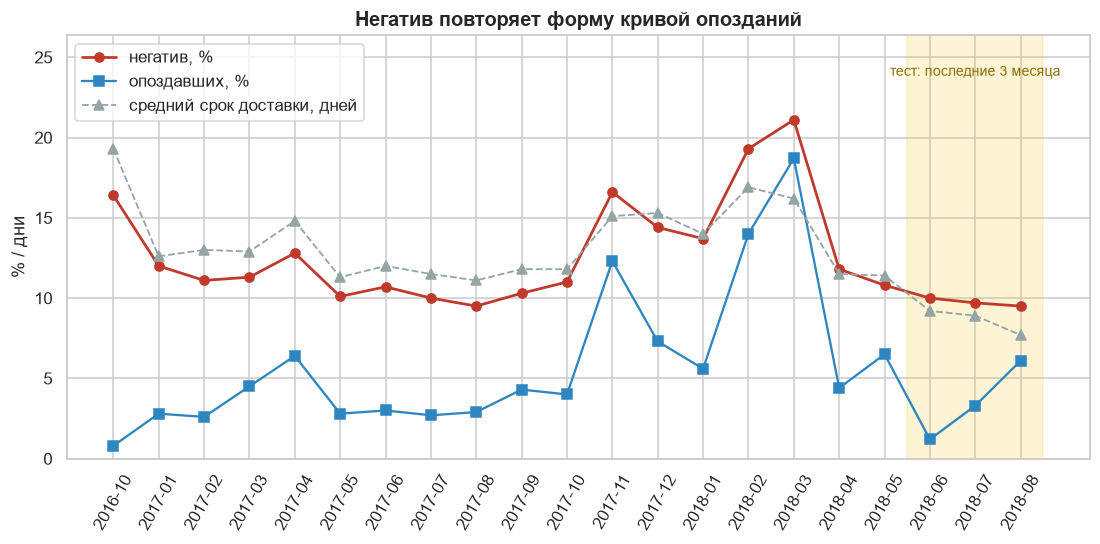

,purchase_year_month,orders,bad_review_pct,late_pct,avg_delivery_days
11,2017-09,4118,10.3,4.3,11.8
12,2017-10,4446,11.0,4.0,11.8
13,2017-11,7237,16.6,12.3,15.1
14,2017-12,5461,14.4,7.3,15.3
15,2018-01,7013,13.7,5.6,14.0
16,2018-02,6507,19.3,14.0,16.9
17,2018-03,6948,21.1,18.7,16.2
18,2018-04,6752,11.8,4.4,11.5
19,2018-05,6722,10.8,6.5,11.4
20,2018-06,6072,10.0,1.2,9.2


In [12]:
a9 = q("A9")
a9_plot = a9[a9.orders >= 100].copy()  # 2016-09 и 2016-12 — по одному заказу

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(a9_plot.purchase_year_month, a9_plot.bad_review_pct,
        color=BAD, marker="o", lw=1.8, label="негатив, %")
ax.plot(a9_plot.purchase_year_month, a9_plot.late_pct,
        color=OK, marker="s", lw=1.5, label="опоздавших, %")
ax.plot(a9_plot.purchase_year_month, a9_plot.avg_delivery_days,
        color=GREY, marker="^", lw=1.2, ls="--", label="средний срок доставки, дней")
ax.axvspan(len(a9_plot) - 3.5, len(a9_plot) - 0.5, color="#f0c419", alpha=0.18)
ax.set_ylim(0, a9_plot.bad_review_pct.max() * 1.25)
ax.text(len(a9_plot) - 2, a9_plot.bad_review_pct.max() * 1.13,
        "тест: последние 3 месяца", ha="center", fontsize=9, color="#8a6d00")
ax.set_title("Негатив повторяет форму кривой опозданий")
ax.set_ylabel("% / дни")
ax.tick_params(axis="x", labelrotation=60)
ax.legend(loc="upper left")
save(fig, "09_monthly_dynamics.png")
plt.show()

a9_plot.tail(12)

**Вывод.** Три кривые идут почти синхронно, и это главный аргумент в пользу
логистического объяснения. Оба всплеска негатива совпадают с провалами
в доставке, а не с изменениями ассортимента или цен: ноябрь 2017 года
(16,6 % негатива при 12,3 % опозданий, чёрная пятница) и февраль–март 2018 года
(19,3 % и 21,1 % при 14,0 % и 18,7 % опозданий). К августу 2018 года средний
срок доставки упал с 16,2 до 7,7 дня, и негатив вернулся к 9,5 %.

Отсюда схема валидации: делим выборку **по времени**, а не случайно.
В тест уходят последние три месяца, июнь–август 2018: это 18 520 заказов,
19,3 % выборки. Случайное разбиение здесь льстило бы модели. Заказы одного
месяца делят общую логистическую обстановку, и если соседние заказы попадут
и в обучение, и в тест, метрика окажется завышенной.

---
## 10. Контроль: штат или всё-таки срок доставки?

[A10] Контроль главного фактора: штаты в разрезе «в срок / опоздал»


сохранено: reports/figures/10_state_controlled_by_delay.png


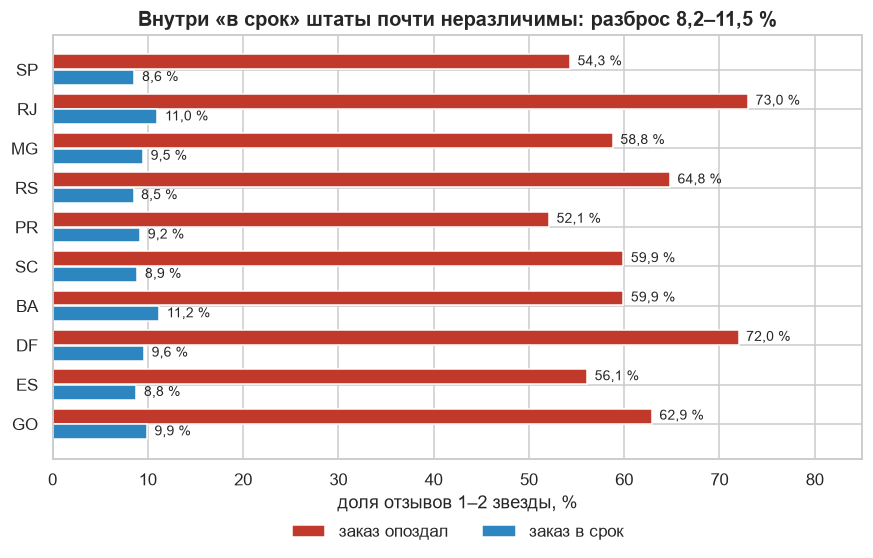

[A10] Контроль главного фактора: штаты в разрезе «в срок / опоздал»


,customer_state,orders,late_pct,bad_pct_on_time,bad_pct_late,bad_pct_total
0,SP,40266,4.4,8.6,54.3,10.7
1,RJ,12211,11.9,11.0,73.0,18.4
2,MG,11285,4.5,9.5,58.8,11.7
3,RS,5326,6.0,8.5,64.8,11.9
4,PR,4900,4.0,9.2,52.1,10.9
5,SC,3519,8.1,8.9,59.9,13.0
6,BA,3229,11.9,11.2,59.9,17.0
7,DF,2070,5.7,9.6,72.0,13.1
8,ES,1969,10.4,8.8,56.1,13.8
9,GO,1946,6.4,9.9,62.9,13.3


In [13]:
a10 = q("A10").head(10).sort_values("orders")

y = range(len(a10))
fig, ax = plt.subplots(figsize=(9.5, 5))
ax.barh([i + 0.2 for i in y], a10.bad_pct_late, height=0.38, color=BAD, label="заказ опоздал")
ax.barh([i - 0.2 for i in y], a10.bad_pct_on_time, height=0.38, color=OK, label="заказ в срок")
ax.set_yticks(list(y))
ax.set_yticklabels(a10.customer_state)
for i, (on_time, late) in enumerate(zip(a10.bad_pct_on_time, a10.bad_pct_late)):
    ax.text(late + 0.8, i + 0.2, pc(late), va="center", fontsize=9)
    ax.text(on_time + 0.8, i - 0.2, pc(on_time), va="center", fontsize=9)
ax.set_title("Внутри «в срок» штаты почти неразличимы: разброс 8,2–11,5 %")
ax.set_xlabel("доля отзывов 1–2 звезды, %")
ax.set_xlim(0, 85)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=2, frameon=False)
save(fig, "10_state_controlled_by_delay.png")
plt.show()

q("A10")

**Вывод.** Этот разрез закрывает вопрос о «региональном характере» негатива.
Если смотреть на общий уровень, то по 17 штатам с объёмом от 500 заказов он
гуляет от 10,7 % (SP) до 19,9 % (MA), почти двукратная разница. Но стоит
зафиксировать факт опоздания, и разброс схлопывается: среди доставленных
в срок все штаты укладываются в коридор 8,2–11,5 %, среди опоздавших —
в 52,1–73,0 %. Значит, штат работает почти исключительно через вероятность
сорвать срок, собственного эффекта у региона почти нет.

Для модели это означает, что поверх логистических признаков штат добавляет
мало и при отборе, скорее всего, окажется внизу permutation importance.
Для бизнеса — что «плохим» регионам не нужна отдельная программа лояльности,
им нужен реалистичный срок доставки в карточке товара.

---
## Итоги EDA

1. **Логистика — главный и почти единственный сильный фактор.** Опоздание
   относительно обещанной даты меняет долю негатива с 9 % до 80 %. Сами
   опоздавшие заказы занимают 6,7 % выборки, но дают 32,5 % всего негатива.
2. **Важен не сам срок, а нарушенное обещание.** Приехать сильно раньше почти
   ничего не даёт: 9,2 % негатива при доставке на 16+ дней раньше против
   11,3 % при доставке на 1–3 дня раньше. Зато один день опоздания поднимает
   негатив с 12,3 % до 32,2 %.
3. **Товарные и платёжные признаки слабые.** Разброс по категориям 5 п. п.,
   по способу оплаты 2,5 п. п. Это фон, а не сигнал.
4. **Сложные заказы стоят особняком.** Несколько продавцов в одном заказе дают
   до 64 % негатива при нормальных сроках. Вероятная причина — частичная
   доставка, но в этих данных её не видно.
5. **География вторична.** Эффект штата целиком объясняется вероятностью
   сорвать срок.
6. **Данные чистые.** Максимум пропусков в одной колонке 1,41 %, стратегия
   заполнения описана в разделе 6.

**Что из этого следует для блока ML (`03_modeling.ipynb`):**

- ядро признаков: `delay_vs_estimate_days`, `is_late`, `delivery_days`,
  `promised_window_days`, `carrier_vs_limit_days`;
- второй эшелон: состав заказа (`items_count`, `distinct_sellers`), категория
  в виде топ-N + `other`, штат, цена и доля доставки в чеке;
- разбиение train/test по времени, тест — июнь–август 2018 (18 520 заказов);
- метрика PR-AUC, baseline — `DummyClassifier` и логистическая регрессия;
- дозаполнение пропусков считаем по train и переносим на test.

Отдельно про корректность постановки: все признаки витрины известны в момент
вручения заказа, это точка отсечки. Ни одно поле таблицы отзывов, кроме самой
оценки, в витрину не попадает, и проверка стоит прямо
в `src/build_features.py`.

In [14]:
conn.close()
print("готово: все разрезы посчитаны в SQL, графики лежат в reports/figures/")

готово: все разрезы посчитаны в SQL, графики лежат в reports/figures/
